In [ ]:
# !pip install factor_analyzer

In [1]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_excel('Cleaned_Dataset 2.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])

Bartlett's P-Value: 0.0
KMO Overall: 0.591158827336815


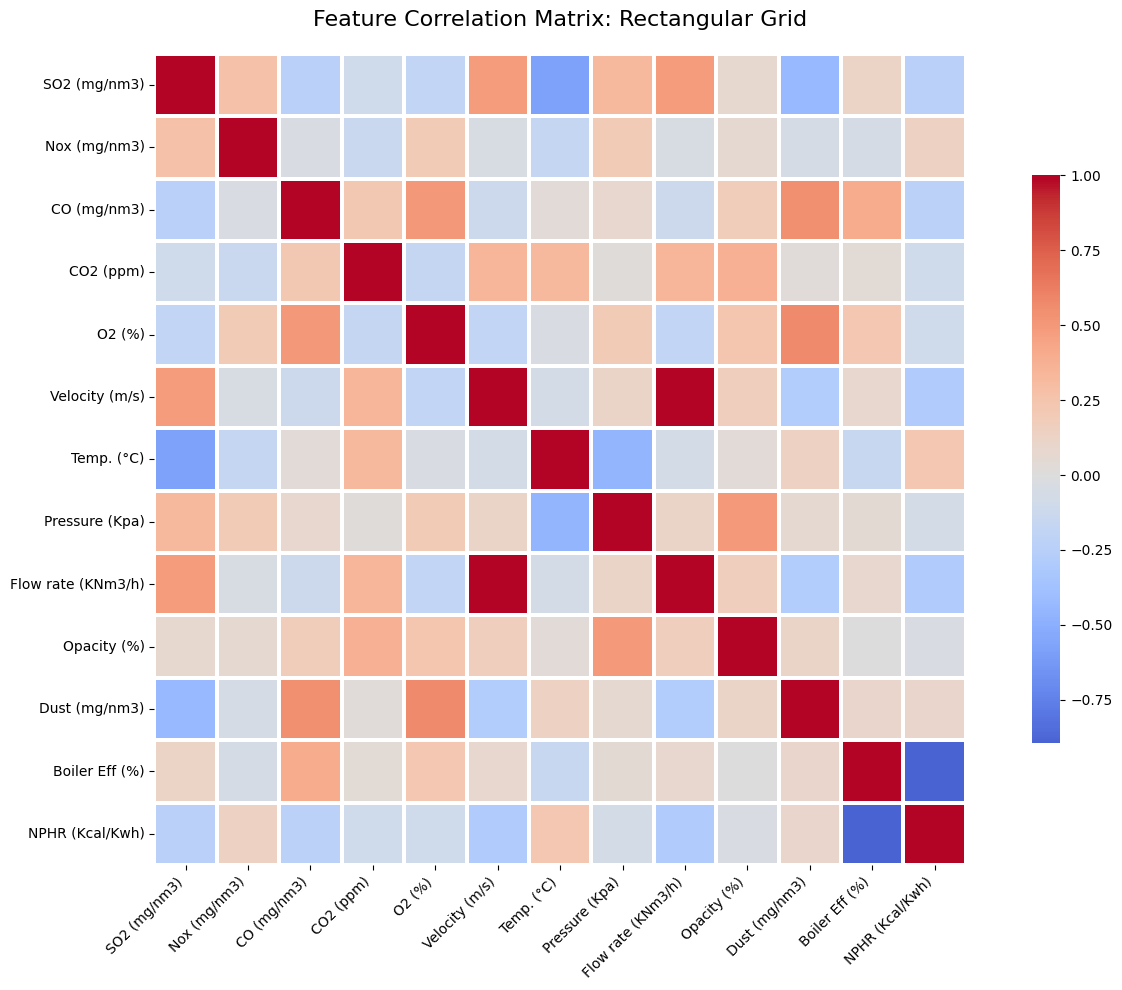

In [2]:
# Select only numeric columns to avoid processing text/IDs
# 1. Select only numeric data
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Convert to numpy array to bypass the library compatibility error
data_array = numeric_df.values

# 2. Calculate the Correlation Matrix manually
corr_matrix = numeric_df.corr()

# Re-run Factor Suitability (KMO & Bartlett)
chi_square_value, p_value = calculate_bartlett_sphericity(data_array)
kmo_all, kmo_model = calculate_kmo(data_array)
print(f"Bartlett's P-Value: {p_value}")
print(f"KMO Overall: {kmo_model}")

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the visual style and figure size
plt.figure(figsize=(14, 10))

# 2. Generate the Rectangle Box Heatmap
# We remove 'mask' to show the full rectangle box
sns.heatmap(corr_matrix, 
            annot=False,          # Show the correlation coefficients
            fmt=".2f",           # Format to 2 decimal places
            cmap='coolwarm',       # Red-Blue palette (Standard for EFA)
            center=0,            # 0 is the neutral white color
            square=True,         # Ensures each cell is a perfect square
            linewidths=1.5,      # Thickens the "box" borders
            linecolor='white',   # Adds white borders to create distinct boxes
            cbar_kws={"shrink": .7})

# 3. Add labels and title
plt.title('Feature Correlation Matrix: Rectangular Grid', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rotates labels for better readability
plt.yticks(rotation=0)

plt.tight_layout() #

In [3]:
# 1. Definisikan Target
targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']

# 2. Ambil hanya Fitur Input (Numeric saja, tanpa target)
input_features = [col for col in numeric_df.columns if col not in targets]
data_input_array = numeric_df[input_features].values

# 3. Hitung ulang KMO & Bartlett hanya untuk INPUT
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

chi_square_value, p_value = calculate_bartlett_sphericity(data_input_array)
kmo_all, kmo_model = calculate_kmo(data_input_array)

print(f"Bartlett's P-Value (Inputs Only): {p_value}")
print(f"KMO Overall (Inputs Only): {kmo_model}")

# 4. Tampilkan MSA per variabel untuk memastikan input sudah bersih
kmo_per_variable, _ = calculate_kmo(data_input_array)
kmo_results = pd.DataFrame({'Feature': input_features, 'KMO_MSA': kmo_per_variable})
print("\n=== KMO Per Variable (Input Features Only) ===")
print(kmo_results.sort_values(by='KMO_MSA', ascending=False))

Bartlett's P-Value (Inputs Only): 0.0
KMO Overall (Inputs Only): 0.6221506373843284

=== KMO Per Variable (Input Features Only) ===
               Feature   KMO_MSA
10       Dust (mg/nm3)  0.768651
0         SO2 (mg/nm3)  0.744527
2          CO (mg/nm3)  0.671410
5       Velocity (m/s)  0.605121
8   Flow rate (KNm3/h)  0.605121
4               O2 (%)  0.603892
7       Pressure (Kpa)  0.588589
3            CO2 (ppm)  0.565864
6           Temp. (°C)  0.557201
1         Nox (mg/nm3)  0.517296
9          Opacity (%)  0.507981


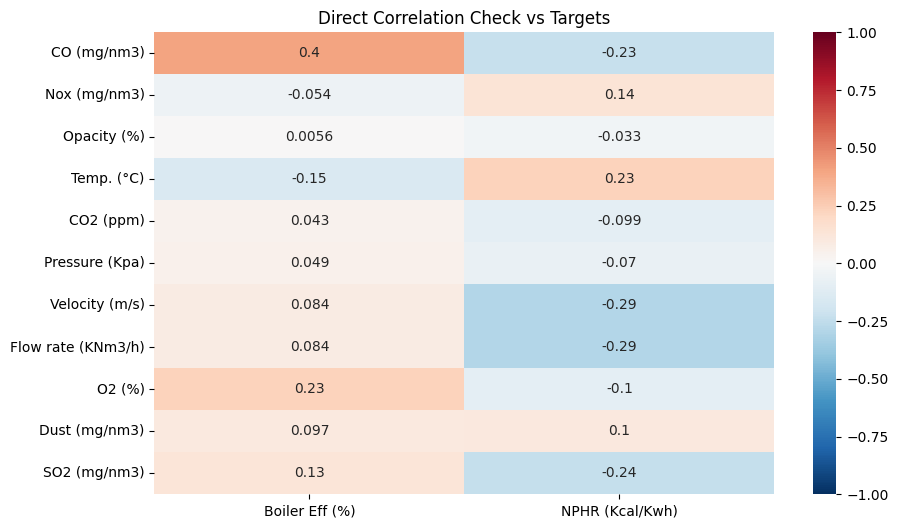

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisikan Target dan Fitur yang memiliki KMO rendah (MSA < 0.6)
targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']
low_kmo_features = ['CO (mg/nm3)','Nox (mg/nm3)', 'Opacity (%)', 'Temp. (°C)', 'CO2 (ppm)', 'Pressure (Kpa)','Velocity (m/s)','Flow rate (KNm3/h)','O2 (%)','Dust (mg/nm3)','SO2 (mg/nm3)']

# 2. Hitung Matriks Korelasi khusus untuk fitur-fitur tersebut terhadap target
# Pastikan menggunakan data numerik yang sudah di-dropna
correlation_check = numeric_df[low_kmo_features + targets].corr()

# 3. Ambil subset korelasi: Fitur vs Target saja
feature_vs_target_corr = correlation_check.loc[low_kmo_features, targets]

# 4. Visualisasi untuk mempermudah pengambilan keputusan
plt.figure(figsize=(10, 6))
sns.heatmap(feature_vs_target_corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Direct Correlation Check vs Targets')
plt.show()



SO2 (mg/nm3)  dan Dust (mg/nm3) dimasukkan dalam fitur terseleksi karena nilai KMO nya yang tinggi >0,7

In [5]:
import pandas as pd


# Load your dataset
df = pd.read_excel('Cleaned_Dataset 2.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])

In [6]:
df

,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3),Boiler Eff (%),NPHR (Kcal/Kwh)
0,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452,77.915748,2607.270106
1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812,76.294873,2687.121676
2,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701,77.886219,2663.032090
3,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674,78.367624,2651.943177
4,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205,77.856369,2651.524408
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,488.715044,122.735621,791.996076,103745.535498,6.027527,12.955925,108.685235,-0.287959,498.582860,49.763117,7.591082,89.855113,2362.587163
545,485.453714,141.549158,792.244088,102865.219610,6.173781,12.270126,106.464384,-0.221320,472.191265,49.763391,7.572601,88.052730,2421.984297
546,492.223928,150.265522,792.396151,103531.566803,6.020364,12.097462,102.674362,-0.106860,465.546617,49.768304,7.570885,85.018900,2522.739965
547,500.705083,135.204496,791.685285,105029.048393,5.799353,12.569459,108.668248,-0.113589,483.710499,49.766662,7.570648,83.295960,2584.543200


In [7]:
# 2. Definisikan daftar fitur yang ingin dipertahankan (Keep List)
# Pastikan penulisan nama kolom di list ini sama persis dengan yang ada di file Excel
# Updated features_to_keep berdasarkan Hasil Akhir VIF: BOILER EFFICIENCY MODEL
features_to_keep = [
   'CO (mg/nm3)',
   'O2 (%)',
   'Dust (mg/nm3)',
   'SO2 (mg/nm3)',
    'Boiler Eff (%)'  # Target Variable
]

# 3. Filter DataFrame (Hanya mengambil kolom di atas)
# Menggunakan 'errors=ignore' agar tidak crash jika ada typo, 
# tapi disarankan nama kolom diperiksa kembali.
df_final = df[df.columns.intersection(features_to_keep)]

# 4. Tampilkan info singkat untuk memastikan kolom lain sudah terhapus
print("Jumlah kolom awal:", df.shape[1])
print("Jumlah kolom sekarang:", df_final.shape[1])
print("\nDaftar kolom yang tersisa:")
print(df_final.columns.tolist())

# Jika ingin menyimpan hasil filter ini ke file baru
df_final.to_excel('#2 final feature selected dataset 2 for boiler efficiency.xlsx', index=False)

Jumlah kolom awal: 13
Jumlah kolom sekarang: 5

Daftar kolom yang tersisa:
['SO2 (mg/nm3)', 'CO (mg/nm3)', 'O2 (%)', 'Dust (mg/nm3)', 'Boiler Eff (%)']


In [8]:
df_final

,SO2 (mg/nm3),CO (mg/nm3),O2 (%),Dust (mg/nm3),Boiler Eff (%)
0,467.109710,675.494230,5.733319,0.269452,77.915748
1,487.997713,677.919792,5.007743,0.270812,76.294873
2,498.073246,679.644721,4.783563,0.272701,77.886219
3,503.058633,682.033313,4.842330,0.274674,78.367624
4,450.895453,478.544209,5.686940,0.283205,77.856369
...,...,...,...,...,...
544,488.715044,791.996076,6.027527,7.591082,89.855113
545,485.453714,792.244088,6.173781,7.572601,88.052730
546,492.223928,792.396151,6.020364,7.570885,85.018900
547,500.705083,791.685285,5.799353,7.570648,83.295960


In [9]:
import pandas as pd


# Load your dataset
df = pd.read_excel('Cleaned_Dataset 2.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])

In [ ]:
df

In [11]:
# 2. Definisikan daftar fitur yang ingin dipertahankan (NPHR MODEL - 7 Features + Target)
# Pastikan simbol seperti (℃) atau (°C) sama persis dengan yang ada di Excel kamu
# Updated features_to_keep berdasarkan Hasil Akhir VIF: NPHR MODEL
features_to_keep_nphr = [
    'CO (mg/nm3)',
    'Temp. (°C)',
    'Flow rate (KNm3/h)',
    'SO2 (mg/nm3)',
    'NPHR (Kcal/Kwh)'  # Target Variable
]

# 3. Filter DataFrame
# Menggunakan intersection untuk memastikan hanya kolom yang ada di list DAN di excel yang diambil
df_final_nphr = df[df.columns.intersection(features_to_keep_nphr)]


# 4. Tampilkan info singkat untuk memastikan kolom lain sudah terhapus
print("Jumlah kolom awal:", df.shape[1])
print("Jumlah kolom sekarang:", df_final_nphr.shape[1])
print("\nDaftar kolom yang tersisa:")
print(df_final_nphr.columns.tolist())

# Jika ingin menyimpan hasil filter ini ke file baru
df_final_nphr.to_excel('#2 final feature selected dataset 2 for nphr.xlsx', index=False)

Jumlah kolom awal: 13
Jumlah kolom sekarang: 5

Daftar kolom yang tersisa:
['SO2 (mg/nm3)', 'CO (mg/nm3)', 'Temp. (°C)', 'Flow rate (KNm3/h)', 'NPHR (Kcal/Kwh)']


In [ ]:
df_final

In [ ]:
# # 3. Calculate Eigenvalues manually using Numpy
# # This completely bypasses the FactorAnalyzer.fit() bug
# eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# # 4. Sort eigenvalues in descending order
# ev_sorted = sorted(eigenvalues, reverse=True)

# # 5. Plotting the Scree Plot
# plt.figure(figsize=(10, 6))
# plt.scatter(range(1, len(ev_sorted) + 1), ev_sorted, color='blue')
# plt.plot(range(1, len(ev_sorted) + 1), ev_sorted, color='blue', label='Eigenvalues')
# plt.title('Scree Plot', fontsize=14)
# plt.xlabel('Number of Factors')
# plt.ylabel('Eigenvalue')

# # Kaiser Criterion line (The standard for feature selection)
# plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (y=1)')
# plt.legend()
# plt.grid(True)
# plt.show()

# # 6. Count and print eigenvalues > 1
# n_factors_recommended = len([i for i in ev_sorted if i > 1])
# print(f"Number of factors with Eigenvalue > 1: {n_factors_recommended}")
# print("Eigenvalues List:", [round(x, 3) for x in ev_sorted])

In [ ]:
# # Use the n_factors_recommended from the previous step
# n = n_factors_recommended 

# # Calculate the Loadings for the top 'n' factors
# # We take the first 'n' eigenvectors and scale them by sqrt(eigenvalues)
# extracted_loadings = eigenvectors[:, :n] * np.sqrt(ev_sorted[:n])

# # Create a clean DataFrame for the Pattern Matrix
# pattern_matrix = pd.DataFrame(
#     extracted_loadings, 
#     index=numeric_df.columns, 
#     columns=[f'Factor_{i+1}' for i in range(n)]
# )

# print("--- Manual Pattern Matrix (Feature Loadings) ---")
# print(pattern_matrix.round(3))

In [ ]:
# # 4. Visualisasi dengan Heatmap untuk melihat perbedaan
# plt.figure(figsize=(12, 12))
# sns.heatmap(pattern_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
# plt.title('Varimax Rotated Loadings (Better Sparsity)', fontsize=16)
# plt.show()

In [ ]:
# from factor_analyzer import Rotator
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Inisialisasi Rotator Varimax
# rotator = Rotator(method='varimax')

# # 2. Lakukan Rotasi pada Loading yang sudah diekstrak (n=6)
# # extracted_loadings adalah hasil dari langkah sebelumnya (eigenvectors * sqrt(ev))
# rotated_loadings = rotator.fit_transform(extracted_loadings)

# # 3. Buat Dataframe Pattern Matrix yang sudah Terotasi
# rotated_pattern_matrix = pd.DataFrame(
#     rotated_loadings,
#     index=numeric_df.columns,
#     columns=[f'Factor_{i+1}' for i in range(n)]
# )

# print("--- Rotated Pattern Matrix (Varimax Orthogonal) ---")
# print(rotated_pattern_matrix.round(3))

# # 4. Visualisasi dengan Heatmap untuk melihat perbedaan
# plt.figure(figsize=(12, 12))
# sns.heatmap(rotated_pattern_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
# plt.title('Varimax Rotated Loadings (Better Sparsity)', fontsize=16)
# plt.show()

In [ ]:
# # 2. Seleksi fitur dengan loading > 0.5 (Absolute)
# threshold = 0.5
# selected_features = []

# for col in rotated_pattern_matrix.columns:
#     # Ambil fitur yang signifikan di tiap faktor
#     top_features = rotated_pattern_matrix[abs(rotated_pattern_matrix[col]) >= threshold].index.tolist()
#     selected_features.extend(top_features)

# # 3. Pembersihan: Hapus duplikat dan buang target
# selected_features = list(set(selected_features))
# targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']
# final_inputs = [f for f in selected_features if f not in targets]

# print(f"Total fitur terpilih untuk model: {len(final_inputs)}")
# print("Daftar Fitur:", final_inputs)
# final_inputs

In [ ]:
# # --- 1. Jalankan Perhitungan Korelasi ---
# corr_matrix = numeric_df[final_inputs + ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']].corr()

# # 4. Visualisasi dengan Heatmap untuk melihat perbedaan
# plt.figure(figsize=(12, 12))
# sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, fmt='.2f')
# plt.title('Correlation Matrix of Selected Features', fontsize=16)
# plt.show()

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # --- 1. Persiapan Data ---
# candidates = [f for f in final_inputs if f not in ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']]
# targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']

# # Hitung korelasi
# corr_matrix = df[candidates + targets].corr()

# # --- 2. Pemisahan Berdasarkan Korelasi Tertinggi (Tanpa Threshold) ---
# inputs_for_boiler = []
# inputs_for_nphr = []

# for feature in candidates:
#     corr_to_boiler = abs(corr_matrix.loc[feature, 'Boiler Eff (%)'])
#     corr_to_nphr = abs(corr_matrix.loc[feature, 'NPHR (Kcal/Kwh)'])
    
#     # Bandingkan mana yang lebih kuat
#     if corr_to_boiler > corr_to_nphr:
#         inputs_for_boiler.append(feature)
#     else:
#         inputs_for_nphr.append(feature)

# # --- 3. Print Hasil ---
# print(f"Total kandidat fitur: {len(candidates)}")
# print(f"---")
# print(f"Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): {len(inputs_for_boiler)}")
# print(f"Daftar: {inputs_for_boiler}\n")
# print(f"Fitur terpilih untuk NPHR (Hubungan Terkuat): {len(inputs_for_nphr)}")
# print(f"Daftar: {inputs_for_nphr}")

# # --- 4. Visualisasi Perbandingan ---
# # Kita visualisasikan fitur Boiler Eff dan NPHR secara terpisah untuk melihat kontrasnya
# fig, ax = plt.subplots(1, 2, figsize=(15, 10))

# # Heatmap untuk Boiler Eff Features
# if inputs_for_boiler:
#     sns.heatmap(corr_matrix.loc[inputs_for_boiler, ['Boiler Eff (%)']], 
#                 annot=True, cmap='RdBu', center=0, ax=ax[0])
#     ax[0].set_title('Features Strongest to Boiler Eff')

# # Heatmap untuk NPHR Features
# if inputs_for_nphr:
#     sns.heatmap(corr_matrix.loc[inputs_for_nphr, ['NPHR (Kcal/Kwh)']], 
#                 annot=True, cmap='RdBu', center=0, ax=ax[1])
#     ax[1].set_title('Features Strongest to NPHR')

# plt.tight_layout()
# plt.show()

In [ ]:
# print(f"Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): {len(inputs_for_boiler)}")
# inputs_for_boiler

In [ ]:
# print(f"Fitur terpilih untuk NPHR (Hubungan Terkuat): {len(inputs_for_nphr)}")
# inputs_for_nphr

In [ ]:
# # --- 1. Tentukan Fitur yang Signifikan untuk Masing-Masing (EFA + Correlation) ---
# # Kita gunakan threshold kecil (misal 0.2) untuk melihat potensi fitur "Shared"
# threshold_shared = 0.2

# sig_boiler = corr_matrix[abs(corr_matrix['Boiler Eff (%)']) >= threshold_shared].index.tolist()
# sig_nphr = corr_matrix[abs(corr_matrix['NPHR (Kcal/Kwh)']) >= threshold_shared].index.tolist()

# # Bersihkan dari target itu sendiri
# sig_boiler = [f for f in sig_boiler if f not in targets]
# sig_nphr = [f for f in sig_nphr if f not in targets]

# # --- 2. Cari Irisan (Intersection) ---
# shared_features = list(set(sig_boiler) & set(sig_nphr))
# only_boiler = list(set(sig_boiler) - set(sig_nphr))
# only_nphr = list(set(sig_nphr) - set(sig_boiler))

# # --- 3. Print Hasil Analisis ---
# print(f"Fitur yang BISA digunakan di KEDUA model: {len(shared_features)}")
# print(f"Daftar Shared: {shared_features}\n")

# print(f"Fitur UNIK untuk Boiler saja: {only_boiler}")
# print(f"Fitur UNIK untuk NPHR saja: {only_nphr}")

# # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
# plt.figure(figsize=(10, 6))
# if shared_features:
#     sns.heatmap(corr_matrix.loc[shared_features, targets], annot=True, cmap='RdBu', center=0)
#     plt.title('Shared Features: Correlation Strength to Both Targets')
#     plt.show()
#     shared_features

#         # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
# plt.figure(figsize=(10, 6))
# if only_boiler:
#     sns.heatmap(corr_matrix.loc[only_boiler, targets], annot=True, cmap='RdBu', center=0)
#     plt.title('Unique Features for Boiler: Correlation Strength to Both Targets')
#     plt.show()
#     only_boiler

#         # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
# plt.figure(figsize=(10, 6))
# if only_nphr:
#     sns.heatmap(corr_matrix.loc[only_nphr, targets], annot=True, cmap='RdBu', center=0)
#     plt.title('Unique Features for NPHR: Correlation Strength to Both Targets')
#     plt.show()
#     only_nphr



In [ ]:
# print ('Fitur Terpilih Untuk Boiler Efficiency')
# shared_features,only_boiler

In [ ]:
# print ('Fitur Terpilih Untuk NPHR')
# shared_features,only_nphr

In [ ]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant
# from sklearn.preprocessing import StandardScaler

# def calculate_vif_scaled(data_frame, feature_list):
#     """
#     Menghitung VIF setelah melakukan Standard Scaling untuk stabilitas numerik.
#     """
#     if not feature_list:
#         return pd.DataFrame(columns=["Feature", "VIF"])
        
#     # 1. Ambil data dan bersihkan NaN
#     X = data_frame[feature_list].copy().dropna()
    
#     if X.empty:
#         return "Dataset kosong setelah dropna()."

#     # 2. Standard Scaling
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)
    
#     # 3. Buat DataFrame baru dari hasil scaling
#     X_scaled_df = pd.DataFrame(X_scaled, columns=feature_list)
    
#     # 4. Tambahkan konstanta (Intersept)
#     X_scaled_df = add_constant(X_scaled_df)
    
#     # 5. Hitung VIF
#     vif_data = pd.DataFrame()
#     vif_data["Feature"] = X_scaled_df.columns
    
#     vif_list = []
#     for i in range(len(X_scaled_df.columns)):
#         try:
#             vif = variance_inflation_factor(X_scaled_df.values, i)
#         except:
#             vif = float('inf')
#         vif_list.append(vif)
        
#     vif_data["VIF"] = vif_list
    
#     # Menghapus baris 'const' dan urutkan
#     return vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

# # --- 1. Gabungkan fitur untuk masing-masing model ---
# final_inputs_boiler = list(set(shared_features + only_boiler))
# final_inputs_nphr = list(set(shared_features + only_nphr))

# # --- 2. Hitung VIF untuk Model Boiler ---
# print("=== VIF Analysis: Boiler Efficiency Model (Scaled) ===")
# vif_boiler = calculate_vif_scaled(df, final_inputs_boiler)
# print(vif_boiler)
# print("\n")

# # --- 3. Hitung VIF untuk Model NPHR ---
# print("=== VIF Analysis: NPHR Model (Scaled) ===")
# vif_nphr = calculate_vif_scaled(df, final_inputs_nphr)
# print(vif_nphr)

# # --- 4. Visualisasi VIF (Boiler) ---
# plt.figure(figsize=(10, 6))
# # Gunakan log scale jika ada nilai INF agar plot tidak hancur
# sns.barplot(x='VIF', y='Feature', data=vif_boiler.replace(float('inf'), 100), palette='viridis')
# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.title('VIF Scores for Boiler Efficiency (Values > 100 clipped for viz)')
# plt.legend()
# plt.show()

# # --- 5. Visualisasi VIF (NPHR) ---
# plt.figure(figsize=(10, 6))
# sns.barplot(x='VIF', y='Feature', data=vif_nphr.replace(float('inf'), 100), palette='magma')
# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.title('VIF Scores for NPHR (Values > 100 clipped for viz)')
# plt.legend()
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant

# def auto_clean_vif(data_frame, feature_list, threshold=10.0):
#     """
#     Calculates VIF and removes the feature with the highest VIF one by one
#     until all features have a VIF < threshold.
#     """
#     # 1. Prepare data (Drop NaNs)
#     X = data_frame[feature_list].copy().dropna()
    
#     while True:
#         # Add constant for VIF calculation
#         X_const = add_constant(X)
#         vif_list = []
#         for i in range(len(X_const.columns)):
#             try:
#                 # Use scalar divide handling to prevent crashes on 'inf'
#                 vif = variance_inflation_factor(X_const.values, i)
#             except:
#                 vif = float('inf')
#             vif_list.append(vif)
            
#         vif_df = pd.DataFrame({'Feature': X_const.columns, 'VIF': vif_list})
#         vif_df = vif_df[vif_df['Feature'] != 'const']
        
#         max_vif = vif_df['VIF'].max()
        
#         # If the highest VIF is still above threshold, drop that feature
#         if max_vif > threshold or np.isinf(max_vif):
#             feature_to_drop = vif_df.sort_values('VIF', ascending=False)['Feature'].iloc[0]
#             print(f"Removing '{feature_to_drop}' (VIF: {max_vif:.2f})")
#             X = X.drop(columns=[feature_to_drop])
#         else:
#             break
            
#     return X.columns.tolist(), vif_df

# # --- EKSEKUSI PEMBERSIHAN ---

# print("=== Cleaning Boiler Model Features ===")
# refined_boiler_features, final_vif_boiler = auto_clean_vif(df, final_inputs_boiler)

# # Tampilkan Hasil Akhir Boiler
# print("\n--- HASIL AKHIR VIF: BOILER EFFICIENCY MODEL ---")
# print(final_vif_boiler.sort_values(by="VIF", ascending=False).reset_index(drop=True))

# print("\n" + "="*50 + "\n")

# print("=== Cleaning NPHR Model Features ===")
# refined_nphr_features, final_vif_nphr = auto_clean_vif(df, final_inputs_nphr)

# # Tampilkan Hasil Akhir NPHR
# print("\n--- HASIL AKHIR VIF: NPHR MODEL ---")
# print(final_vif_nphr.sort_values(by="VIF", ascending=False).reset_index(drop=True))

In [ ]:
# # --- 4. Visualisasi VIF (Boiler) ---
# plt.figure(figsize=(10, 6))

# # Pastikan data diurutkan agar grafik mudah dibaca
# vif_boiler_sorted = final_vif_boiler.sort_values(by='VIF', ascending=False)

# # Menggunakan 'hue' untuk menghindari FutureWarning
# sns.barplot(
#     x='VIF', 
#     y='Feature', 
#     data=vif_boiler_sorted, 
#     hue='Feature', 
#     palette='viridis', 
#     legend=False
# )

# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.axvline(x=5, color='orange', linestyle=':', label='Ideal Threshold (5)')
# plt.title('Final VIF Scores: Boiler Efficiency Model', fontsize=14)
# plt.xlabel('VIF Value')
# plt.ylabel('Selected Features')
# plt.legend()
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.show()

# # --- 5. Visualisasi VIF (NPHR) ---
# plt.figure(figsize=(10, 6))

# # Pastikan data diurutkan
# vif_nphr_sorted = final_vif_nphr.sort_values(by='VIF', ascending=False)

# sns.barplot(
#     x='VIF', 
#     y='Feature', 
#     data=vif_nphr_sorted, 
#     hue='Feature', 
#     palette='magma', 
#     legend=False
# )

# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.axvline(x=5, color='orange', linestyle=':', label='Ideal Threshold (5)')
# plt.title('Final VIF Scores: NPHR Model', fontsize=14)
# plt.xlabel('VIF Value')
# plt.ylabel('Selected Features')
# plt.legend()
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.show()